# Dev / test notebook for adapting DEAR codebase


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import logging
import torch 

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('..')

import src.data_utils as dut

In [3]:
sys.path.append('../../colab-code/')

In [4]:
from bgm import BGM, BigJointDiscriminator

## Set up namespace, e.g. point to data

In [5]:
data_path = '../data'
res_path = '../../colab-code/results/xView_0/'

In [6]:
to_di = lambda x: dict( [y.split(':') for y in x.split('\t')[-1].split(',')])

rename_di = {
    'D loss' : 'disc',
    ' Encoder loss' : 'enc',
    ' Decoder loss' : 'dec',
    ' Sup loss' : 'sup',
    ' E_score' : 'enc_',
    ' D score' : 'dec_'
}

def parse_log( log_path):
    log_lines = dut.to_from_text( log_path).split('\n')
    df = pd.DataFrame([to_di(y) for y in log_lines[:-1]]).astype(float)
    df.rename( columns= rename_di, inplace= True)
    return df

## Investigate data, try things out 

_**you can even add fancy markdown throughout to document things..?**_

In [9]:
os.listdir(res_path)

['config.txt', 'log.txt', 'model50.sav']

In [10]:
log_path = f'{res_path}log.txt'

In [78]:
df = parse_log( log_path)
df.shape

(300, 6)

In [79]:
df.head(3)

,disc,enc,dec,sup,enc_,dec_
0,1.3946,1.1356,0.6007,0.9192,0.2163,-1.2014
1,0.3958,1.7573,0.8622,-0.1921,1.9495,-1.7236
2,0.1599,4.9415,1.2894,0.2130,4.7285,-2.5788


<Axes: >

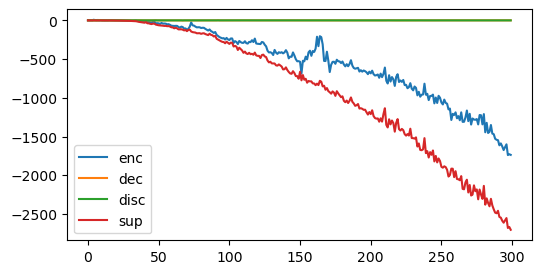

In [83]:
_, ax = plt.subplots( figsize= (6,3))
df[['enc','dec','disc','sup']].plot( ax= ax)

<Axes: >

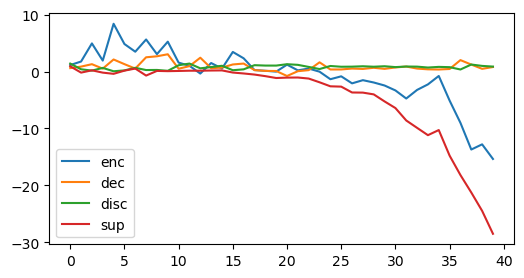

In [89]:
_, ax = plt.subplots( figsize= (6,3))
df[['enc','dec','disc','sup']].head(40).plot( ax= ax)

In [153]:
get_name_from_batch = lambda x: f'model{x}.sav'
get_batch_from_name = lambda x: int( x.split('.sav')[0].split('model')[-1])
device = torch.device('cpu')

def load_dear_config( config_path):
    # DEAR-main config is just a plain-text file..
    # TODO: amend
    config_lines = dut.to_from_text( config_path).split('\n')[:-1]
    values = []
    for v in [x.split(':')[1].strip() for x in c_lines]:
        try:
            v = int(v)
        except ValueError:
            try:
                v = float(v)
            except ValueError:
                pass
        values.append(v)
    return dict(zip([x.split(':')[0].strip() for x in c_lines], values))

def load_from_checkpoint( folder, checkpoint= None, with_disc= False):
    # need to know the configuration:
    config_path = f'{folder}config.txt'
    # and need an existing checkpoint:
    if checkpoint is None:
        checkpoints_at = [get_batch_from_name(x) for x in os.listdir( folder) if x.endswith('.sav')]
        checkpoint = get_name_from_batch( max( checkpoints_at))
    elif type(checkpoint) == int:
        checkpoint = get_name_from_batch( checkpoint)
    checkpoint_path = f'{folder}{checkpoint}'
    assert os.path.exists( checkpoint_path)
    
    # load config for initialising the architecture correctly:
    
    # TODO: remove hard-coding!!!
    # TODO: make an option for no causal prior
    A_init = torch.load( '../data/xView_0/A_T.pt')
    n_nodes, _ = A_init.shape
    model = BGM( 
        config_dict['latent_dim'], config_dict['g_conv_dim'], config_dict['image_size'],
        config_dict['enc_dist'], config_dict['enc_arch'], config_dict['enc_fc_size'], config_dict['enc_noise_dim'],
        config_dict['dec_dist'], config_dict['prior'], n_nodes, A_init
    )
    checkpoint_data = torch.load( checkpoint_path, map_location= device)
    model.load_state_dict( checkpoint_data[ 'model'])
    if with_disc:
        discriminator = BigJointDiscriminator( 
            config_dict['latent_dim'], config_dict['d_conv_dim'], config_dict['image_size'], config_dict['dis_fc_size']
        )
        discriminator.load_state_dict( checkpoint_data[ 'discriminator'])
        
    else:
        discriminator = None
    del checkpoint_data
    print(f'Loaded model from {checkpoint_path}')
    return config_dict, model, discriminator
    

In [154]:
config_dict, model, _ = load_from_checkpoint( res_path)

Loaded model from ../../colab-code/results/xView_0/model50.sav


In [133]:
config_dict['dataset'], config_dict['data_dir']

('xView_0', 'data-test/xView_0/')

In [134]:
A_init = torch.load( '../data/xView_0/A_T.pt')
n_nodes, _ = A_init.shape
model = BGM( 
    config_dict['latent_dim'], config_dict['g_conv_dim'], config_dict['image_size'],
    config_dict['enc_dist'], config_dict['enc_arch'], config_dict['enc_fc_size'], config_dict['enc_noise_dim'],
    config_dict['dec_dist'], config_dict['prior'], n_nodes, A_init
)

In [117]:
# map names of the causal nodes to the index of the column in label.csv file
labels_index_di = {
    'buildings': 2,
    'roads': 3,
    'cars': 4,
}
labels_ordered = ['buildings','roads','cars']
# provide the causal structure as tuples of (parent,child)
causal_ordering = [
    ('buildings','roads'),
    ('roads','cars'),
    ('buildings','cars')
]


In [106]:
labels = set([])
for x in causal_ordering:
    labels = labels | set(x)
labels

{'buildings', 'cars', 'roads'}

In [120]:
def adjacency_from_tuples( causal_ordering, labels_ordered):
    """
    NOTE: this returns the *transpose* of adjacency matrix, as this is what the DEAR framework 
    uses as input format; they refer to it as A, but typical causal notation is A_T, hence our notation.
    """
    n_nodes = len( labels_ordered)
    labels_enum_di =  dict(zip( labels_ordered, range( n_nodes)))
    A_T = torch.zeros( (n_nodes, n_nodes))
    for parent, child in causal_ordering:
        parent_id, child_id = labels_enum_di[ parent], labels_enum_di[ child]
        A_T[ parent_id, child_id] = 1
    return A_T

In [122]:
A_T = adjacency_from_tuples( causal_ordering, labels_ordered)

In [129]:
torch.save( A_T, f='../data/xView_0/A_T.pt')

In [130]:
torch.load( '../data/xView_0/A_T.pt')

tensor([[0., 1., 1.],
        [0., 0., 1.],
        [0., 0., 0.]])